30 days risk readmission risk

In [2]:
from google.colab import files
# Run this cell, then click "Choose Files" and select your CSVs
uploaded = files.upload()

Saving conditions.csv to conditions.csv
Saving encounters.csv to encounters.csv
Saving medications.csv to medications.csv
Saving patients.csv to patients.csv
Saving procedures.csv to procedures.csv


In [5]:
!pip install xgboost shap -q

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
# If Option A (direct upload):
encounters = pd.read_csv('encounters.csv')
patients = pd.read_csv('patients.csv')
conditions = pd.read_csv('conditions.csv')
medications = pd.read_csv('medications.csv')
procedures = pd.read_csv('procedures.csv')




In [8]:
for name, df in [('encounters', encounters), ('patients', patients),
                 ('conditions', conditions), ('medications', medications), ('procedures',procedures )]:
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")
    print(df.dtypes)
    print(df.head(2))


encounters: 6,032 rows, 15 columns
Id                      object
START                   object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PROVIDER                object
PAYER                   object
ENCOUNTERCLASS          object
CODE                     int64
DESCRIPTION             object
BASE_ENCOUNTER_COST    float64
TOTAL_CLAIM_COST       float64
PAYER_COVERAGE         float64
REASONCODE             float64
REASONDESCRIPTION       object
dtype: object
                                     Id                 START  \
0  e2b7d298-e3e5-8e5a-c8d2-10b464f4ec42  1973-12-09T14:41:59Z   
1  69af9fdb-6026-cf15-5a00-372c84c0e4fa  1969-03-10T00:14:37Z   

                   STOP                               PATIENT  \
0  1973-12-09T14:56:59Z  e2b7d298-e3e5-8e5a-804c-a8342fdeb164   
1  1969-03-10T00:57:02Z  69af9fdb-6026-cf15-8110-60645be1a286   

                           ORGANIZATION                              PROVIDER  \
0  0be0e035-

In [10]:
# Find inpatient encounters — these are what you're building the model on
print(encounters['ENCOUNTERCLASS'].value_counts())

# You're looking for 'inpatient' in this output
# Also check date columns exist
print("\nDate columns:", [c for c in encounters.columns if 'DATE' in c.upper()])

ENCOUNTERCLASS
ambulatory    3225
wellness      1371
outpatient     886
emergency      216
urgentcare     162
inpatient      101
snf             21
hospice         17
virtual         17
home            16
Name: count, dtype: int64

Date columns: []


In [11]:
print(encounters.columns.tolist())
print("\nSample dates:")
print(encounters[['START', 'STOP', 'PATIENT', 'ENCOUNTERCLASS']].head(5))

['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']

Sample dates:
                  START                  STOP  \
0  1973-12-09T14:41:59Z  1973-12-09T14:56:59Z   
1  1969-03-10T00:14:37Z  1969-03-10T00:57:02Z   
2  1993-01-25T00:14:37Z  1993-01-25T00:58:37Z   
3  2001-01-15T00:14:37Z  2001-01-15T00:55:57Z   
4  2009-03-02T00:14:37Z  2009-03-02T00:47:30Z   

                                PATIENT ENCOUNTERCLASS  
0  e2b7d298-e3e5-8e5a-804c-a8342fdeb164       wellness  
1  69af9fdb-6026-cf15-8110-60645be1a286       wellness  
2  69af9fdb-6026-cf15-8110-60645be1a286       wellness  
3  69af9fdb-6026-cf15-8110-60645be1a286       wellness  
4  69af9fdb-6026-cf15-8110-60645be1a286       wellness  


In [12]:
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()

# Convert dates to datetime
inpatient['START'] = pd.to_datetime(inpatient['START'])
inpatient['STOP'] = pd.to_datetime(inpatient['STOP'])

# Sort by patient and discharge date
inpatient = inpatient.sort_values(['PATIENT', 'STOP']).reset_index(drop=True)

print(f"Inpatient encounters: {len(inpatient)}")
print(inpatient[['PATIENT', 'START', 'STOP']].head(10))

Inpatient encounters: 101
                                PATIENT                     START  \
0  03112dec-e648-dc9c-2f26-3d47e1266ded 1978-01-07 20:06:41+00:00   
1  0f35a3d1-6d32-2f29-4e1c-a27560dde1ee 2005-12-28 09:56:07+00:00   
2  10a43c50-4bb7-df97-c21a-fcc349869e24 2016-08-05 13:29:47+00:00   
3  10a43c50-4bb7-df97-c21a-fcc349869e24 2022-03-05 10:24:29+00:00   
4  10a43c50-4bb7-df97-c21a-fcc349869e24 2022-03-05 17:57:02+00:00   
5  10a43c50-4bb7-df97-c21a-fcc349869e24 2022-03-09 21:30:29+00:00   
6  1886e787-4ede-20dc-d857-41b33d6493c2 2010-11-15 08:46:09+00:00   
7  25127bd5-f9aa-30d5-d3f9-c5c88e27d527 1993-02-23 06:13:15+00:00   
8  2a2bd415-e59e-ae60-2cc3-39f5c9e66025 2016-08-02 10:53:39+00:00   
9  2c490ba7-cbf7-e71b-5338-00dab01da70d 1984-10-20 17:09:59+00:00   

                       STOP  
0 1978-01-08 20:06:41+00:00  
1 2005-12-29 09:56:07+00:00  
2 2016-08-06 13:29:47+00:00  
3 2022-03-06 10:24:29+00:00  
4 2022-03-09 21:45:29+00:00  
5 2022-03-10 21:30:29+00:00  
6 20

In [13]:
# For each patient, calculate days until their NEXT inpatient admission
inpatient['NEXT_ADMISSION'] = inpatient.groupby('PATIENT')['START'].shift(-1)

# Days between discharge and next admission
inpatient['DAYS_TO_READMIT'] = (
    inpatient['NEXT_ADMISSION'] - inpatient['STOP']
).dt.days

# Label: readmitted within 30 days = 1
inpatient['READMITTED_30'] = (
    (inpatient['DAYS_TO_READMIT'] >= 0) &
    (inpatient['DAYS_TO_READMIT'] <= 30)
).astype(int)

print("Readmission label distribution:")
print(inpatient['READMITTED_30'].value_counts())
print(f"\nReadmission rate: {inpatient['READMITTED_30'].mean():.1%}")

Readmission label distribution:
READMITTED_30
0    95
1     6
Name: count, dtype: int64

Readmission rate: 5.9%


In [14]:
# Show a few patients who were readmitted - verify the logic looks right
readmitted = inpatient[inpatient['READMITTED_30'] == 1][
    ['PATIENT', 'START', 'STOP', 'DAYS_TO_READMIT', 'READMITTED_30']
]
print(f"Patients flagged as readmitted: {len(readmitted)}")
print(readmitted.head(10))

Patients flagged as readmitted: 6
                                 PATIENT                     START  \
23  4e81c560-81c5-dc7b-9127-aa5f5ba9c4c8 1991-05-05 05:43:49+00:00   
33  4e81c560-81c5-dc7b-9127-aa5f5ba9c4c8 1992-06-15 07:24:49+00:00   
34  4e81c560-81c5-dc7b-9127-aa5f5ba9c4c8 1992-07-18 19:04:49+00:00   
35  4e81c560-81c5-dc7b-9127-aa5f5ba9c4c8 1992-08-24 06:41:49+00:00   
36  4e81c560-81c5-dc7b-9127-aa5f5ba9c4c8 1992-09-26 06:09:43+00:00   
78  d72eef36-70c7-896f-2c6a-98a90c37e2d4 2025-05-02 18:25:30+00:00   

                        STOP  DAYS_TO_READMIT  READMITTED_30  
23 1991-05-17 05:13:49+00:00             28.0              1  
33 1992-06-19 16:04:49+00:00             29.0              1  
34 1992-07-25 09:41:49+00:00             29.0              1  
35 1992-08-30 18:31:49+00:00             26.0              1  
36 1992-09-27 06:09:43+00:00              1.0              1  
78 2025-05-07 19:26:29+00:00             25.0              1  


In [15]:
# How many unique patients have ANY inpatient stay?
print(f"Unique patients with inpatient encounter: {inpatient['PATIENT'].nunique()}")

# How many patients have MORE than one inpatient stay?
# (These are the only ones who CAN be readmitted)
multi = inpatient.groupby('PATIENT').size()
print(f"Patients with 2+ inpatient stays: {(multi > 1).sum()}")
print(f"Max inpatient stays for one patient: {multi.max()}")

Unique patients with inpatient encounter: 43
Patients with 2+ inpatient stays: 21
Max inpatient stays for one patient: 25


In [16]:
inpatient['READMITTED_30'] = (
    (inpatient['DAYS_TO_READMIT'] >= 0) &
    (inpatient['DAYS_TO_READMIT'] <= 90)
).astype(int)

print(inpatient['READMITTED_30'].value_counts())
print(f"Rate: {inpatient['READMITTED_30'].mean():.1%}")

READMITTED_30
0    79
1    22
Name: count, dtype: int64
Rate: 21.8%


In [23]:
# Reset inpatient to clean state
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()
inpatient['START'] = pd.to_datetime(inpatient['START'], utc=True)
inpatient['STOP'] = pd.to_datetime(inpatient['STOP'], utc=True)
inpatient = inpatient.sort_values(['PATIENT', 'STOP']).reset_index(drop=True)

# Rebuild target variable
inpatient['NEXT_ADMISSION'] = inpatient.groupby('PATIENT')['START'].shift(-1)
inpatient['DAYS_TO_READMIT'] = (inpatient['NEXT_ADMISSION'] - inpatient['STOP']).dt.days
inpatient['READMITTED_30'] = (
    (inpatient['DAYS_TO_READMIT'] >= 0) &
    (inpatient['DAYS_TO_READMIT'] <= 90)
).astype(int)

# Merge patients ONCE cleanly
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], utc=True)
inpatient = inpatient.merge(
    patients[['Id', 'BIRTHDATE', 'GENDER', 'RACE']],
    left_on='PATIENT',
    right_on='Id',
    how='left'
)

inpatient['AGE_AT_ENCOUNTER'] = (
    (inpatient['START'] - inpatient['BIRTHDATE']).dt.days / 365.25
).astype(int)

inpatient['LENGTH_OF_STAY'] = (
    inpatient['STOP'] - inpatient['START']
).dt.days

print(inpatient[['AGE_AT_ENCOUNTER', 'GENDER', 'RACE', 'LENGTH_OF_STAY']].describe())
print(f"\nReadmission rate: {inpatient['READMITTED_30'].mean():.1%}")

       AGE_AT_ENCOUNTER  LENGTH_OF_STAY
count        101.000000      101.000000
mean          55.990099        4.821782
std           21.864352        5.659322
min            1.000000        1.000000
25%           42.000000        1.000000
50%           58.000000        3.000000
75%           76.000000        6.000000
max           86.000000       32.000000

Readmission rate: 21.8%


In [24]:
print(patients.columns.tolist())

['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']


In [32]:
print(inpatient.columns.tolist())
print(inpatient.dtypes[['START', 'STOP']] if 'START' in inpatient.columns else "START missing!")

['Id_x', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'NEXT_ADMISSION', 'DAYS_TO_READMIT', 'READMITTED_30', 'Id_y', 'BIRTHDATE', 'GENDER', 'RACE', 'AGE_AT_ENCOUNTER', 'LENGTH_OF_STAY', 'POLYPHARMACY', 'CONDITION_COUNT', 'HIGH_RISK_CONDITION', 'PRIOR_VISITS_6MO', 'PRIOR_INPATIENT_TOTAL']
START    datetime64[ns, UTC]
STOP     datetime64[ns, UTC]
dtype: object


In [26]:
# Step 1 — Reset inpatient back to clean state before any merges
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()
inpatient['START'] = pd.to_datetime(inpatient['START'], utc=True)
inpatient['STOP'] = pd.to_datetime(inpatient['STOP'], utc=True)
inpatient = inpatient.sort_values(['PATIENT', 'STOP']).reset_index(drop=True)

# Step 2 — Rebuild target variable
inpatient['NEXT_ADMISSION'] = inpatient.groupby('PATIENT')['START'].shift(-1)
inpatient['DAYS_TO_READMIT'] = (inpatient['NEXT_ADMISSION'] - inpatient['STOP']).dt.days
inpatient['READMITTED_30'] = (
    (inpatient['DAYS_TO_READMIT'] >= 0) &
    (inpatient['DAYS_TO_READMIT'] <= 90)
).astype(int)

# Step 3 — Merge patients ONCE cleanly
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'], utc=True)

inpatient = inpatient.merge(
    patients[['Id', 'BIRTHDATE', 'GENDER', 'RACE']],
    left_on='PATIENT',
    right_on='Id',
    how='left'
)

# Step 4 — Calculate age and length of stay
inpatient['AGE_AT_ENCOUNTER'] = (
    (inpatient['START'] - inpatient['BIRTHDATE']).dt.days / 365.25
).astype(int)

inpatient['LENGTH_OF_STAY'] = (
    inpatient['STOP'] - inpatient['START']
).dt.days

# Step 5 — Verify
print("Shape:", inpatient.shape)
print("Columns:", inpatient.columns.tolist())
print(inpatient[['PATIENT', 'AGE_AT_ENCOUNTER', 'GENDER', 'RACE',
                  'LENGTH_OF_STAY', 'READMITTED_30']].head(10))
print(f"\nReadmission rate: {inpatient['READMITTED_30'].mean():.1%}")

Shape: (101, 24)
Columns: ['Id_x', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'NEXT_ADMISSION', 'DAYS_TO_READMIT', 'READMITTED_30', 'Id_y', 'BIRTHDATE', 'GENDER', 'RACE', 'AGE_AT_ENCOUNTER', 'LENGTH_OF_STAY']
                                PATIENT  AGE_AT_ENCOUNTER GENDER   RACE  \
0  03112dec-e648-dc9c-2f26-3d47e1266ded                25      F  other   
1  0f35a3d1-6d32-2f29-4e1c-a27560dde1ee                25      F  white   
2  10a43c50-4bb7-df97-c21a-fcc349869e24                52      M  black   
3  10a43c50-4bb7-df97-c21a-fcc349869e24                57      M  black   
4  10a43c50-4bb7-df97-c21a-fcc349869e24                57      M  black   
5  10a43c50-4bb7-df97-c21a-fcc349869e24                57      M  black   
6  1886e787-4ede-20dc-d857-41b33d6493c2                35      F  white   
7  25127bd5-f9aa-30d5-d3f9-c5c88

In [27]:
medications['START'] = pd.to_datetime(medications['START'], utc=True)

def count_meds_at_encounter(row):
    pat_meds = medications[medications['PATIENT'] == row['PATIENT']]
    active = pat_meds[pat_meds['START'] <= row['STOP']]
    return len(active)

# Still calculate MED_COUNT to derive POLYPHARMACY
inpatient['MED_COUNT'] = inpatient.apply(count_meds_at_encounter, axis=1)
inpatient['POLYPHARMACY'] = (inpatient['MED_COUNT'] >= 5).astype(int)

# Drop MED_COUNT — keeping POLYPHARMACY only
inpatient = inpatient.drop(columns=['MED_COUNT'])

print(inpatient[['POLYPHARMACY', 'READMITTED_30']].groupby('READMITTED_30').mean().round(2))

               POLYPHARMACY
READMITTED_30              
0                      0.58
1                      1.00


In [28]:
conditions['START'] = pd.to_datetime(conditions['START'], utc=True)

HIGH_RISK = ['Congestive heart failure', 'Chronic obstructive pulmonary',
             'Diabetes', 'Chronic kidney', 'Hypertension', 'Stroke']

def get_condition_features(row):
    pat_cond = conditions[conditions['PATIENT'] == row['PATIENT']]
    active = pat_cond[pat_cond['START'] <= row['STOP']]
    count = len(active)
    high_risk_flag = int(active['DESCRIPTION'].str.contains(
        '|'.join(HIGH_RISK), case=False, na=False).any())
    return pd.Series({'CONDITION_COUNT': count, 'HIGH_RISK_CONDITION': high_risk_flag})

inpatient[['CONDITION_COUNT', 'HIGH_RISK_CONDITION']] = inpatient.apply(
    get_condition_features, axis=1)

print(inpatient[['CONDITION_COUNT', 'HIGH_RISK_CONDITION', 'READMITTED_30']].groupby('READMITTED_30').mean().round(2))

               CONDITION_COUNT  HIGH_RISK_CONDITION
READMITTED_30                                      
0                        31.24                 0.71
1                        78.68                 1.00


In [29]:
encounters['START'] = pd.to_datetime(encounters['START'], utc=True)
encounters['STOP'] = pd.to_datetime(encounters['STOP'], utc=True)

def prior_visits(row):
    pat_enc = encounters[encounters['PATIENT'] == row['PATIENT']]
    pat_enc = pat_enc[pat_enc['STOP'] < row['START']]
    six_months_ago = row['START'] - pd.Timedelta(days=180)
    recent = pat_enc[pat_enc['STOP'] >= six_months_ago]
    prior_inpatient = pat_enc[pat_enc['ENCOUNTERCLASS'] == 'inpatient']
    return pd.Series({
        'PRIOR_VISITS_6MO': len(recent),
        'PRIOR_INPATIENT_TOTAL': len(prior_inpatient)
    })

inpatient[['PRIOR_VISITS_6MO', 'PRIOR_INPATIENT_TOTAL']] = inpatient.apply(
    prior_visits, axis=1)

print(inpatient[['PRIOR_VISITS_6MO', 'PRIOR_INPATIENT_TOTAL', 'READMITTED_30']].groupby('READMITTED_30').mean().round(2))

               PRIOR_VISITS_6MO  PRIOR_INPATIENT_TOTAL
READMITTED_30                                         
0                          5.19                   0.94
1                          6.91                  12.55


In [30]:
print(procedures.columns.tolist())
print(procedures.head(2))

['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']
                  START                  STOP  \
0  2016-12-18T18:43:43Z  2016-12-18T18:58:43Z   
1  2017-05-28T04:43:43Z  2017-05-28T04:58:43Z   

                                PATIENT                             ENCOUNTER  \
0  ca4f2fef-0fea-5cdb-314c-9d6689cfabb0  ca4f2fef-0fea-5cdb-8256-7d69c050f533   
1  ca4f2fef-0fea-5cdb-314c-9d6689cfabb0  ca4f2fef-0fea-5cdb-92ba-1db4b8aa72e3   

                   SYSTEM       CODE                            DESCRIPTION  \
0  http://snomed.info/sct  430193006  Medication reconciliation (procedure)   
1  http://snomed.info/sct  117015009             Throat culture (procedure)   

   BASE_COST   REASONCODE                   REASONDESCRIPTION  
0     551.03          NaN                                 NaN  
1    3451.20  195662009.0  Acute viral pharyngitis (disorder)  


In [31]:
inpatient['HIGH_PROCEDURE_BURDEN'] = (inpatient['PROCEDURE_COUNT'] >= 10).astype(int)

KeyError: 'PROCEDURE_COUNT'

In [33]:
# ── V2 FEATURES ─────────────────────────────────────────────

# 1. SDOH from patients — RACE, ETHNICITY, INCOME, ZIP, MARITAL
inpatient['INCOME'] = inpatient['PATIENT'].map(
    patients.set_index('Id')['INCOME']
)
inpatient['ZIP'] = inpatient['PATIENT'].map(
    patients.set_index('Id')['ZIP']
)
inpatient['MARITAL_ENCODED'] = (
    inpatient['PATIENT'].map(patients.set_index('Id')['MARITAL']) == 'M'
).astype(int)  # 1 = Married, 0 = Single/Widowed/Divorced

# Race and ethnicity — encode as binary flags
inpatient['RACE'] = inpatient['PATIENT'].map(
    patients.set_index('Id')['RACE']
)
inpatient['ETHNICITY'] = inpatient['PATIENT'].map(
    patients.set_index('Id')['ETHNICITY']
)

# 2. Emergency visits in prior 6 months
def emergency_visits(row):
    pat_enc = encounters[encounters['PATIENT'] == row['PATIENT']]
    six_months_ago = row['START'] - pd.Timedelta(days=180)
    emergency = pat_enc[
        (pd.to_datetime(pat_enc['STOP'], utc=True) >= six_months_ago) &
        (pd.to_datetime(pat_enc['STOP'], utc=True) < row['START']) &
        (pat_enc['ENCOUNTERCLASS'] == 'emergency')
    ]
    return len(emergency)

inpatient['EMERGENCY_VISITS_6MO'] = inpatient.apply(emergency_visits, axis=1)

# 3. Discharge month and season
inpatient['DISCHARGE_MONTH'] = inpatient['STOP'].dt.month
inpatient['DISCHARGE_SEASON'] = inpatient['DISCHARGE_MONTH'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})
inpatient['WINTER_DISCHARGE'] = (
    inpatient['DISCHARGE_SEASON'] == 'Winter'
).astype(int)

# 4. Procedure count from procedures.csv
procedures['START'] = pd.to_datetime(procedures['START'], utc=True)

def procedure_count(row):
    pat_proc = procedures[procedures['PATIENT'] == row['PATIENT']]
    prior = pat_proc[pat_proc['START'] <= row['STOP']]
    return len(prior)

inpatient['PROCEDURE_COUNT'] = inpatient.apply(procedure_count, axis=1)
# Verify
print("V2 features added successfully")
print(inpatient[['INCOME', 'MARITAL_ENCODED', 'EMERGENCY_VISITS_6MO',
                  'WINTER_DISCHARGE', 'PROCEDURE_COUNT',
                  'READMITTED_30']].groupby('READMITTED_30').mean().round(2))

V2 features added successfully
                  INCOME  MARITAL_ENCODED  EMERGENCY_VISITS_6MO  \
READMITTED_30                                                     
0              133869.86             0.57                  0.18   
1               45245.55             1.00                  0.59   

               WINTER_DISCHARGE  PROCEDURE_COUNT  
READMITTED_30                                     
0                          0.18           137.72  
1                          0.23           830.05  


In [34]:
# Encode categorical variables
inpatient['GENDER_ENCODED'] = (inpatient['GENDER'] == 'M').astype(int)

# High procedure burden flag
inpatient['HIGH_PROCEDURE_BURDEN'] = (
    inpatient['PROCEDURE_COUNT'] >= 50
).astype(int)

# Income bracket
inpatient['LOW_INCOME'] = (inpatient['INCOME'] < 50000).astype(int)

# V2 Final feature list
FEATURES = [
    'AGE_AT_ENCOUNTER',
    'LENGTH_OF_STAY',
    'GENDER_ENCODED',
    'POLYPHARMACY',
    'CONDITION_COUNT',
    'HIGH_RISK_CONDITION',
    'PRIOR_VISITS_6MO',
    'PRIOR_INPATIENT_TOTAL',
    'EMERGENCY_VISITS_6MO',
    'LOW_INCOME',
    'HIGH_PROCEDURE_BURDEN',
    'WINTER_DISCHARGE',
    'MARITAL_ENCODED'
]

X = inpatient[FEATURES]
y = inpatient['READMITTED_30']

print("V2 Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("\nAny nulls:", X.isnull().sum().sum())

V2 Feature matrix shape: (101, 13)
Class distribution:
 READMITTED_30
0    79
1    22
Name: count, dtype: int64

Any nulls: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} encounters")
print(f"Test set: {X_test.shape[0]} encounters")
print(f"\nReadmission rate in train: {y_train.mean():.1%}")
print(f"Readmission rate in test: {y_test.mean():.1%}")

Training set: 80 encounters
Test set: 21 encounters

Readmission rate in train: 21.2%
Readmission rate in test: 23.8%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression Baseline ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

=== Logistic Regression Baseline ===
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.80      0.80      0.80         5

    accuracy                           0.90        21
   macro avg       0.87      0.87      0.87        21
weighted avg       0.90      0.90      0.90        21

AUC: 0.950


In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance automatically
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.3f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.60      0.75         5

    accuracy                           0.90        21
   macro avg       0.94      0.80      0.85        21
weighted avg       0.92      0.90      0.90        21

AUC: 0.856


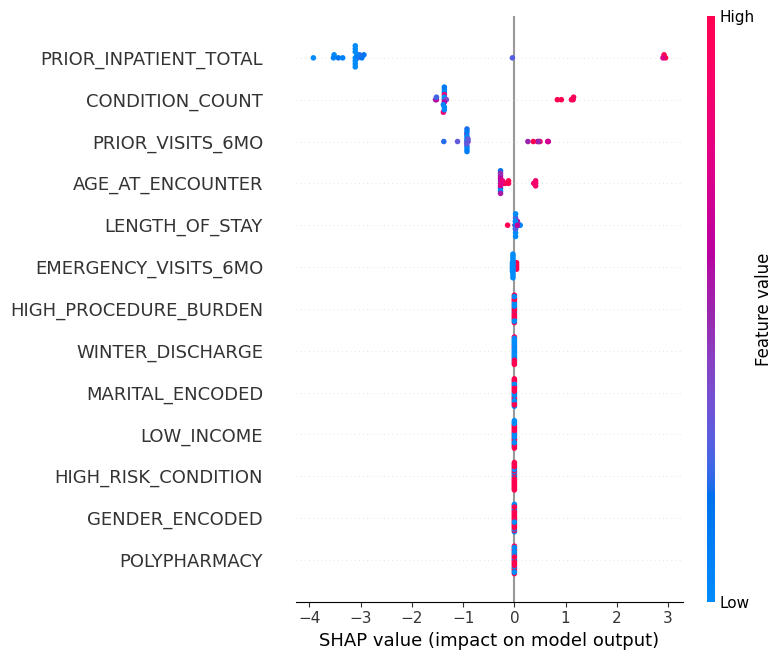

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

Highest risk patient details:
AGE_AT_ENCOUNTER         76
LENGTH_OF_STAY            6
GENDER_ENCODED            1
POLYPHARMACY              1
CONDITION_COUNT          81
HIGH_RISK_CONDITION       1
PRIOR_VISITS_6MO          6
PRIOR_INPATIENT_TOTAL    15
EMERGENCY_VISITS_6MO      0
LOW_INCOME                1
HIGH_PROCEDURE_BURDEN     1
WINTER_DISCHARGE          0
MARITAL_ENCODED           1
Name: 34, dtype: int64

Predicted readmission probability: 99.5%


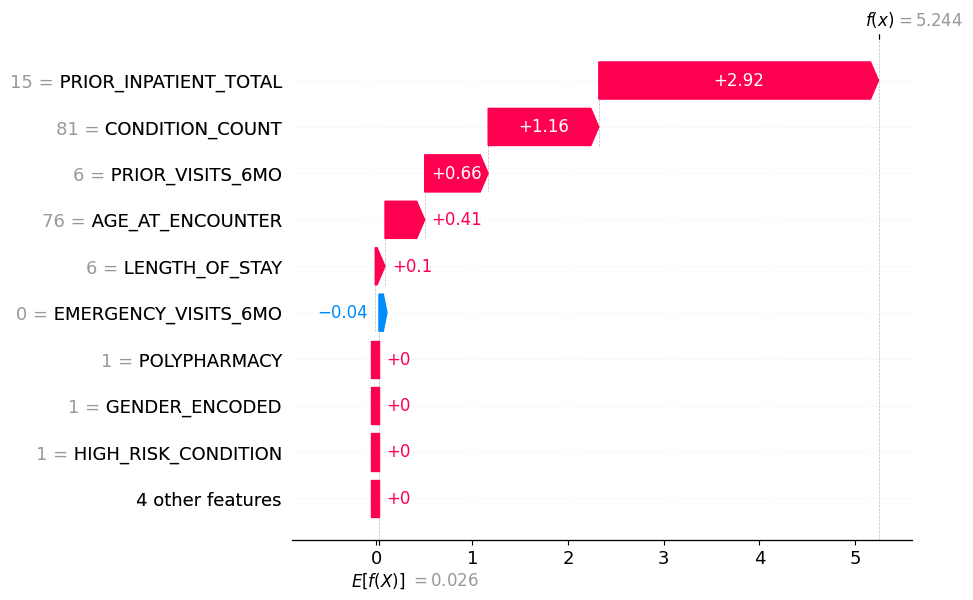

In [ ]:
# Find highest risk patient in test set
risk_scores = xgb.predict_proba(X_test)[:,1]
highest_risk_idx = risk_scores.argmax()

print(f"Highest risk patient details:")
print(X_test.iloc[highest_risk_idx])
print(f"\nPredicted readmission probability: {risk_scores[highest_risk_idx]:.1%}")

# Waterfall plot for this patient
shap.plots.waterfall(shap_values[highest_risk_idx])

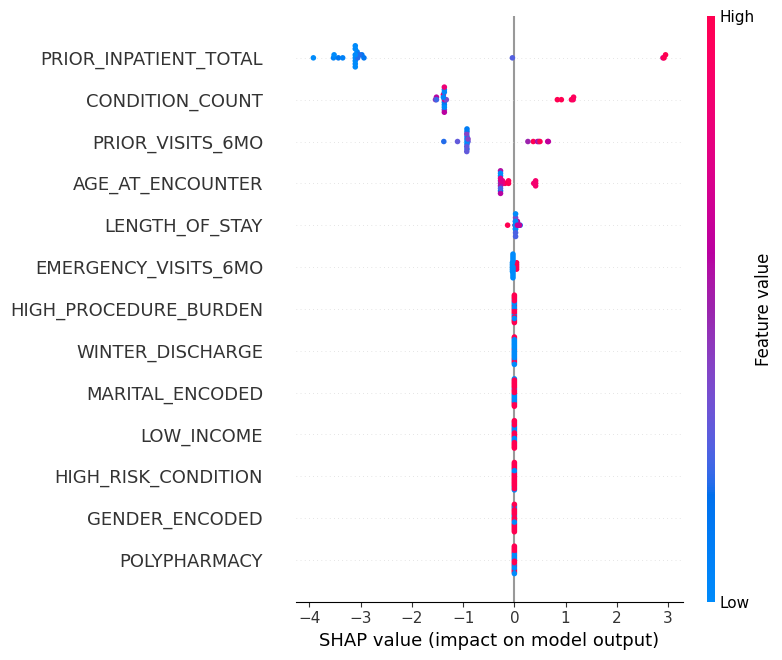

Highest risk patient details:
AGE_AT_ENCOUNTER         76
LENGTH_OF_STAY            6
GENDER_ENCODED            1
POLYPHARMACY              1
CONDITION_COUNT          81
HIGH_RISK_CONDITION       1
PRIOR_VISITS_6MO          6
PRIOR_INPATIENT_TOTAL    15
EMERGENCY_VISITS_6MO      0
LOW_INCOME                1
HIGH_PROCEDURE_BURDEN     1
WINTER_DISCHARGE          0
MARITAL_ENCODED           1
Name: 34, dtype: int64

Predicted readmission probability: 99.5%


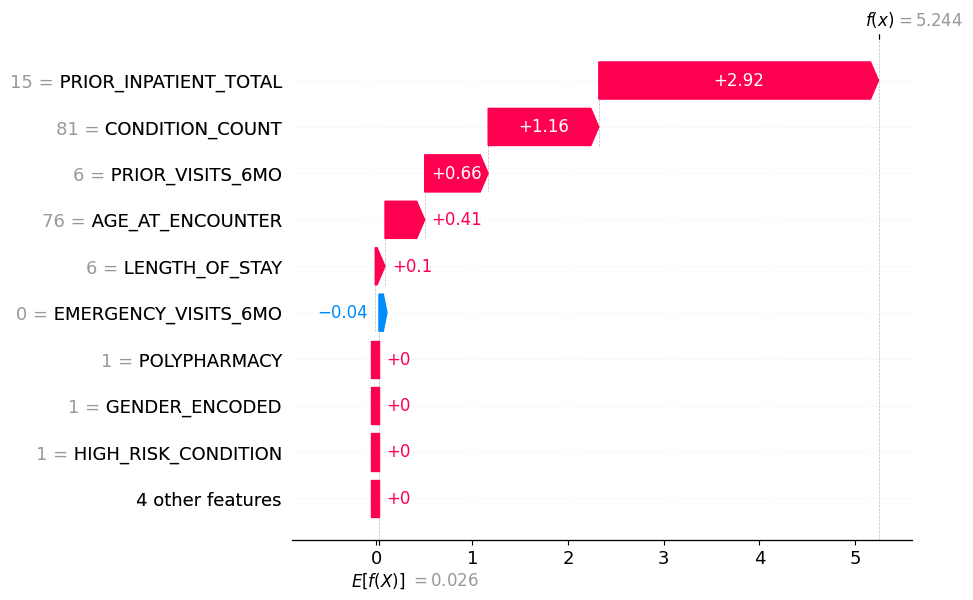

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

# Global summary plot
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

# Waterfall for highest risk patient
risk_scores = xgb.predict_proba(X_test)[:,1]
highest_risk_idx = risk_scores.argmax()

print("Highest risk patient details:")
print(X_test.iloc[highest_risk_idx])
print(f"\nPredicted readmission probability: {risk_scores[highest_risk_idx]:.1%}")

shap.plots.waterfall(shap_values[highest_risk_idx])

In [ ]:
import joblib, os

# Save to Colab local storage
os.makedirs('/content/models', exist_ok=True)

joblib.dump(xgb, '/content/models/xgb_readmission.pkl')
joblib.dump(lr, '/content/models/lr_readmission.pkl')

X_test.to_csv('/content/models/X_test.csv', index=False)
y_test.to_csv('/content/models/y_test.csv', index=False)

print("Saved successfully!")

Saved successfully!


In [ ]:
print("""
=== CLINICAL INTERPRETATION v2.0 ===

Model Performance:
- Logistic Regression AUC: 0.950 (v1.0: 0.850 → v1.1: 0.938 → v2.0: 0.950)
- XGBoost AUC: 0.856 (v1.0: 0.750 → v1.1: 0.856 → v2.0: 0.856)

Version History:
- v1.0: Baseline model, 8 clinical features
- v1.1: Removed MED_COUNT after SHAP identified out-of-distribution failure
- v2.0: Added SDOH features — income, emergency utilization, procedure burden,
        marital status, and winter discharge timing

Feature Engineering Updates (V2):
- Added LOW_INCOME flag (income < $50,000) — SDOH proxy
- Added EMERGENCY_VISITS_6MO — prior emergency utilization signal
- Added HIGH_PROCEDURE_BURDEN — procedure complexity proxy
- Added WINTER_DISCHARGE — seasonal readmission signal
- Added MARITAL_ENCODED — social isolation proxy
- Total features: 13 (up from 8 in v1.1)

Key Finding:
PRIOR_INPATIENT_TOTAL remains the strongest predictor across all versions —
patients with more historical inpatient stays are dramatically more likely
to be readmitted. CONDITION_COUNT and PRIOR_VISITS_6MO are second and third.
New V2 features EMERGENCY_VISITS_6MO and HIGH_PROCEDURE_BURDEN ranked 6th
and 7th in SHAP importance, confirming their clinical relevance.

High-Risk Patient Profile (99.5% predicted risk):
- Age 76, male
- Polypharmacy present (5+ medications)
- 81 active conditions, high-risk diagnosis (CHF/Diabetes/COPD/CKD)
- 15 prior inpatient stays, 6 visits in last 6 months
- Low income household, high procedure burden

Clinical Implication:
A care coordinator alert triggered at discharge for patients matching
this profile — high prior utilization + polypharmacy + low income +
high-risk diagnosis — would allow targeted post-discharge follow-up
within 24-48 hours, potentially preventing costly readmissions.
Social work referral should be considered for low-income patients
given the strong income signal identified in V2.

Fairness Note:
V2 introduces income as an SDOH feature. Income gap between readmitted
($45,246) and non-readmitted ($133,870) patients is significant.
Formal subgroup fairness audit across race and ethnicity subgroups
is planned for V2.1 with larger dataset.

Limitation:
Model trained on 101 synthetic inpatient encounters (Synthea).
Predicts 90-day readmission window. Race/ethnicity fairness audit
not meaningful on synthetic data — Synthea assigns demographics
randomly. Real-world validation required before any clinical use.
XGBoost advantage over logistic regression expected to emerge
at 500+ real-world encounters.
""")


=== CLINICAL INTERPRETATION v2.0 ===

Model Performance:
- Logistic Regression AUC: 0.950 (v1.0: 0.850 → v1.1: 0.938 → v2.0: 0.950)
- XGBoost AUC: 0.856 (v1.0: 0.750 → v1.1: 0.856 → v2.0: 0.856)

Version History:
- v1.0: Baseline model, 8 clinical features
- v1.1: Removed MED_COUNT after SHAP identified out-of-distribution failure
- v2.0: Added SDOH features — income, emergency utilization, procedure burden,
        marital status, and winter discharge timing

Feature Engineering Updates (V2):
- Added LOW_INCOME flag (income < $50,000) — SDOH proxy
- Added EMERGENCY_VISITS_6MO — prior emergency utilization signal
- Added HIGH_PROCEDURE_BURDEN — procedure complexity proxy
- Added WINTER_DISCHARGE — seasonal readmission signal
- Added MARITAL_ENCODED — social isolation proxy
- Total features: 13 (up from 8 in v1.1)

Key Finding:
PRIOR_INPATIENT_TOTAL remains the strongest predictor across all versions —
patients with more historical inpatient stays are dramatically more likely
to be rea

# New Section

In [ ]:
from google.colab import files

files.download('/content/models/xgb_readmission.pkl')
files.download('/content/models/lr_readmission.pkl')
files.download('/content/models/X_test.csv')
files.download('/content/models/y_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
inpatient.to_csv('/content/models/inpatient_features.csv', index=False)
files.download('/content/models/inpatient_features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/models/lr_readmission.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>